# Fragrantica 香水数据分析项目｜第一阶段 EDA

这个 Notebook 是项目第一版起步代码，目标是完成数据概览、基础可视化、核心指标构建和下一步分析方向。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "fra_cleaned.csv"

df = pd.read_csv(data_path, sep=";", encoding="cp1252", decimal=",")
df.head()


,url,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,xerjoff,Italy,unisex,1.42,201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,jean-paul-gaultier,France,women,1.86,70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,jean-paul-gaultier,France,unisex,1.91,285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,https://www.fragrantica.com/perfume/bruno-bana...,pride-edition-man,bruno-banani,Germany,men,1.92,59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,https://www.fragrantica.com/perfume/jean-paul-...,le-male-pride-collector,jean-paul-gaultier,France,men,1.93,632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


In [2]:
# 基础清洗：统一空值、转换数值字段
df.columns = [c.strip() for c in df.columns]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"": np.nan, "nan": np.nan, "unknown": np.nan, "Unknown": np.nan})

df["Rating Value"] = pd.to_numeric(df["Rating Value"], errors="coerce")
df["Rating Count"] = pd.to_numeric(df["Rating Count"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           24063 non-null  object 
 1   Perfume       24063 non-null  object 
 2   Brand         24063 non-null  object 
 3   Country       24063 non-null  object 
 4   Gender        24063 non-null  object 
 5   Rating Value  24063 non-null  float64
 6   Rating Count  24063 non-null  int64  
 7   Year          22026 non-null  float64
 8   Top           24063 non-null  object 
 9   Middle        24063 non-null  object 
 10  Base          24063 non-null  object 
 11  Perfumer1     11743 non-null  object 
 12  Perfumer2     1336 non-null   object 
 13  mainaccord1   24063 non-null  object 
 14  mainaccord2   24050 non-null  object 
 15  mainaccord3   23949 non-null  object 
 16  mainaccord4   23675 non-null  object 
 17  mainaccord5   23082 non-null  object 
dtypes: float64(2), int64(1), o

In [3]:
# 数据概览
overview = pd.DataFrame({
    "Metric": [
        "Rows", "Columns", "Unique perfumes", "Unique brands", "Unique countries",
        "Rating mean", "Rating median", "Rating count median", "Earliest year", "Latest year"
    ],
    "Value": [
        df.shape[0], df.shape[1], df["Perfume"].nunique(), df["Brand"].nunique(), df["Country"].nunique(),
        round(df["Rating Value"].mean(), 3), round(df["Rating Value"].median(), 3),
        round(df["Rating Count"].median(), 1),
        int(df["Year"].min()), int(df["Year"].max())
    ]
})
overview


,Metric,Value
0,Rows,24063.00
1,Columns,18.00
2,Unique perfumes,22840.00
3,Unique brands,1060.00
4,Unique countries,54.00
5,Rating mean,3.96
6,Rating median,3.97
7,Rating count median,127.00
8,Earliest year,1781.00
9,Latest year,2024.00


In [4]:
# 缺失值统计
missing = df.isna().sum().reset_index()
missing.columns = ["Column", "Missing Count"]
missing["Missing Rate"] = (missing["Missing Count"] / len(df)).round(4)
missing.sort_values("Missing Count", ascending=False)


,Column,Missing Count,Missing Rate
12,Perfumer2,22727,0.9445
11,Perfumer1,12320,0.5120
7,Year,2037,0.0847
17,mainaccord5,981,0.0408
16,mainaccord4,388,0.0161
15,mainaccord3,114,0.0047
14,mainaccord2,13,0.0005
10,Base,0,0.0000
13,mainaccord1,0,0.0000
0,url,0,0.0000


In [5]:
# 构造综合热度指标
df["Popularity Score"] = df["Rating Value"] * np.log1p(df["Rating Count"])
df[["Perfume", "Brand", "Rating Value", "Rating Count", "Popularity Score"]].sort_values(
    "Popularity Score", ascending=False
).head(20)


,Perfume,Brand,Rating Value,Rating Count,Popularity Score
23588,dior-homme-intense-2011,dior,4.50,18272,44.159309
23230,la-nuit-de-l-homme,yves-saint-laurent,4.44,19533,43.866808
23914,le-male-le-parfum,jean-paul-gaultier,4.60,13406,43.716248
22149,aventus,creed,4.34,19581,42.889469
21199,terre-d-hermes,hermes,4.28,21347,42.666093
17145,coco-mademoiselle,chanel,4.12,29283,42.373362
20211,tobacco-vanille,tom-ford,4.23,22332,42.358461
23823,le-male-elixir,jean-paul-gaultier,4.56,10388,42.173173
22695,y-eau-de-parfum,yves-saint-laurent,4.38,15024,42.124522
22942,acqua-di-gio-profumo,giorgio-armani,4.41,14072,42.124379


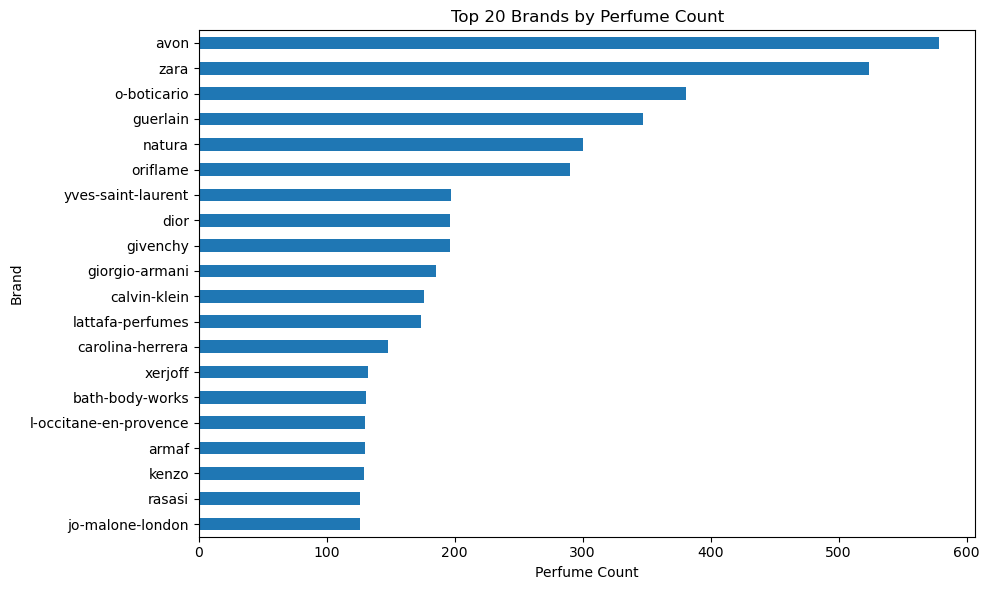

In [6]:
# Top 20 品牌
top_brands = df["Brand"].value_counts().head(20)

plt.figure(figsize=(10, 6))
top_brands.sort_values().plot(kind="barh")
plt.xlabel("Perfume Count")
plt.ylabel("Brand")
plt.title("Top 20 Brands by Perfume Count")
plt.tight_layout()
plt.show()


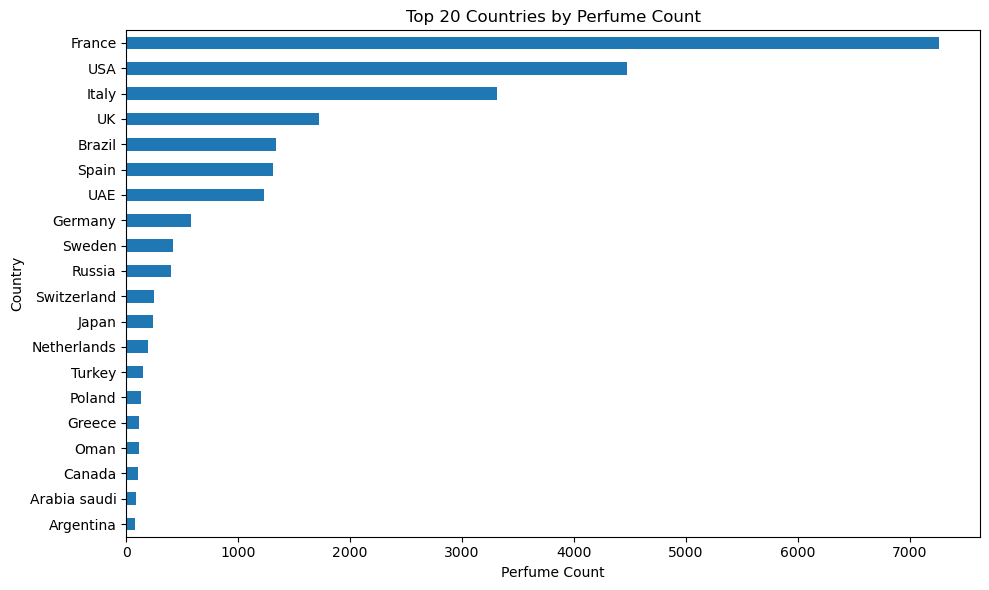

In [7]:
# Top 20 国家
top_countries = df["Country"].value_counts().head(20)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")
plt.xlabel("Perfume Count")
plt.ylabel("Country")
plt.title("Top 20 Countries by Perfume Count")
plt.tight_layout()
plt.show()


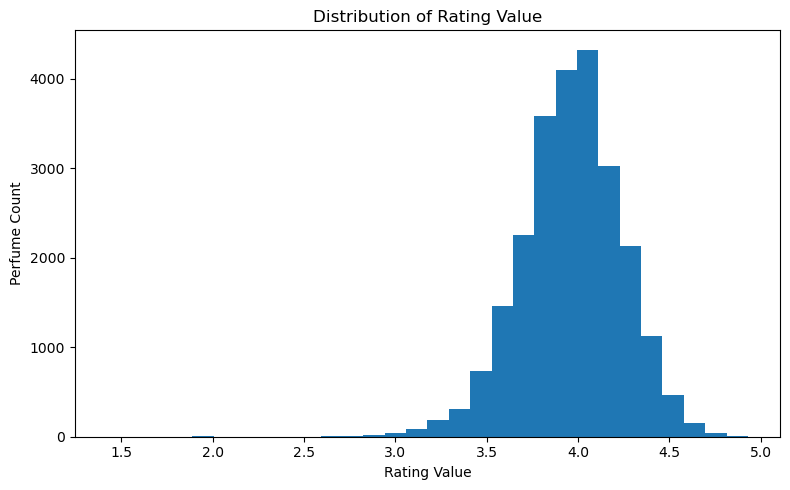

In [8]:
# 评分分布
plt.figure(figsize=(8, 5))
plt.hist(df["Rating Value"].dropna(), bins=30)
plt.xlabel("Rating Value")
plt.ylabel("Perfume Count")
plt.title("Distribution of Rating Value")
plt.tight_layout()
plt.show()


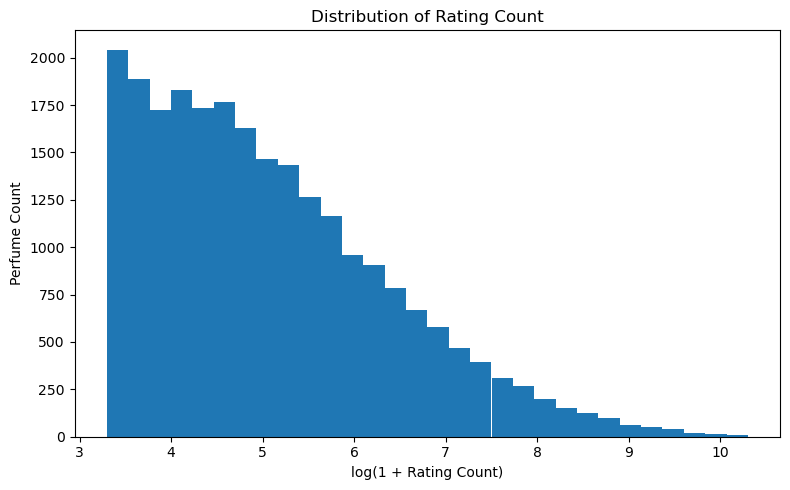

In [9]:
# 评分人数分布，因为极度偏态，所以取 log
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["Rating Count"].dropna()), bins=30)
plt.xlabel("log(1 + Rating Count)")
plt.ylabel("Perfume Count")
plt.title("Distribution of Rating Count")
plt.tight_layout()
plt.show()


In [10]:
# Gender 对比
gender_summary = (
    df.groupby("Gender")
    .agg(
        perfume_count=("Perfume", "count"),
        avg_rating=("Rating Value", "mean"),
        median_rating_count=("Rating Count", "median"),
        avg_popularity_score=("Popularity Score", "mean")
    )
    .sort_values("perfume_count", ascending=False)
    .round(3)
)
gender_summary


,perfume_count,avg_rating,median_rating_count,avg_popularity_score
Gender,,,,
women,11376,3.918,141.0,20.341
unisex,7698,3.984,112.0,19.668
men,4989,4.020,121.0,20.625


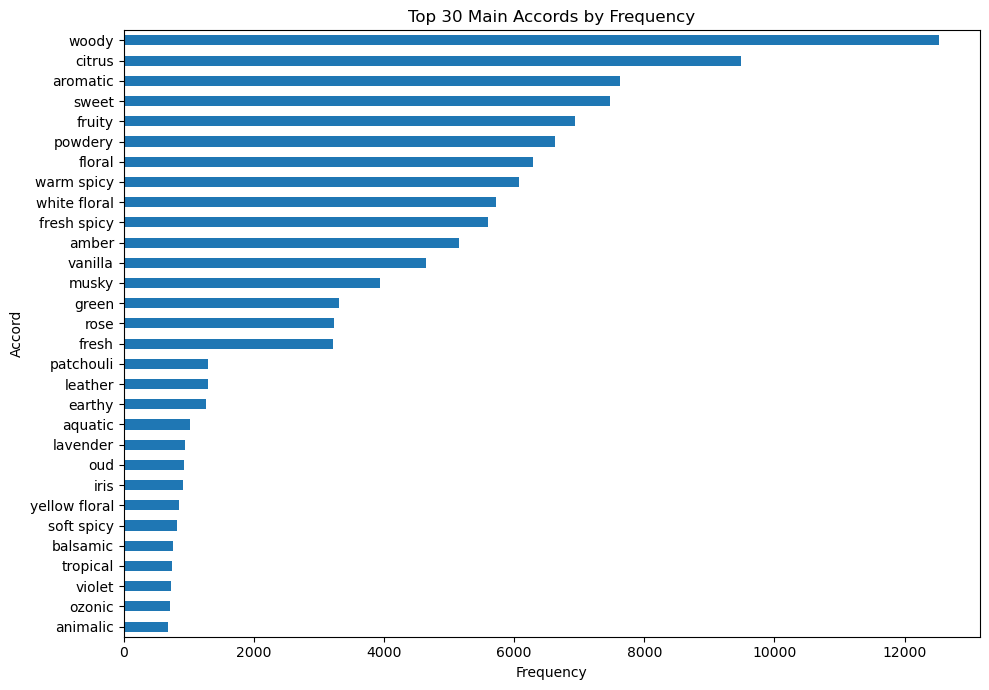

In [11]:
# 主香调频率
accord_cols = [c for c in df.columns if c.startswith("mainaccord")]
accord_long = df[accord_cols].melt(value_name="accord").dropna()
accord_freq = accord_long["accord"].value_counts().head(30)

plt.figure(figsize=(10, 7))
accord_freq.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Accord")
plt.title("Top 30 Main Accords by Frequency")
plt.tight_layout()
plt.show()


In [12]:
# 哪些香调更容易获得高热度
accord_rating_rows = []
for accord in accord_long["accord"].dropna().unique():
    mask = df[accord_cols].eq(accord).any(axis=1)
    subset = df.loc[mask]
    accord_rating_rows.append({
        "Accord": accord,
        "Perfume Count": len(subset),
        "Avg Rating": subset["Rating Value"].mean(),
        "Avg Popularity Score": subset["Popularity Score"].mean()
    })

accord_rating = pd.DataFrame(accord_rating_rows)
accord_rating.query("`Perfume Count` >= 100").sort_values(
    "Avg Popularity Score", ascending=False
).head(25).round(3)


,Accord,Perfume Count,Avg Rating,Avg Popularity Score
45,honey,366,4.007,21.660
24,almond,437,3.996,21.654
54,nutty,273,3.998,21.596
61,cinnamon,479,4.062,21.409
35,coffee,216,4.003,21.362
50,tobacco,408,4.084,21.173
21,vanilla,4644,4.012,21.125
34,lactonic,390,3.912,21.122
48,cacao,218,4.018,20.964
38,smoky,470,4.042,20.916


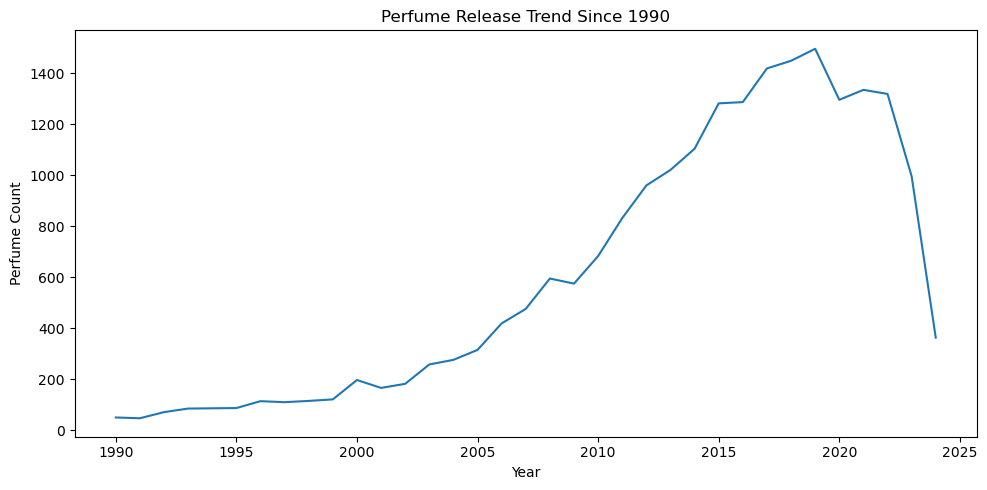

In [13]:
# 年份趋势：1990 年以后更有分析意义
year_trend = (
    df.dropna(subset=["Year"])
    .assign(Year=lambda x: x["Year"].astype(int))
    .groupby("Year")
    .agg(
        perfume_count=("Perfume", "count"),
        avg_rating=("Rating Value", "mean"),
        avg_rating_count=("Rating Count", "mean"),
        avg_popularity_score=("Popularity Score", "mean")
    )
    .reset_index()
)

year_trend_recent = year_trend.query("Year >= 1990")

plt.figure(figsize=(10, 5))
plt.plot(year_trend_recent["Year"], year_trend_recent["perfume_count"])
plt.xlabel("Year")
plt.ylabel("Perfume Count")
plt.title("Perfume Release Trend Since 1990")
plt.tight_layout()
plt.show()


## 下一步建议

第一步先把这些图和表跑通，然后开始写每张图背后的解释。

最重要的不是“图画出来”，而是能回答：

- 这个现象是什么？
- 为什么可能出现？
- 对品牌、市场或用户偏好有什么启发？
- 这个发现能不能指导推荐系统或评分预测模型？

下一步可以继续做“每张图的分析话术”和“项目报告正文”。